# (7065) Fredschaaf: двухзонная астрометрия и звёздная PSF

Обрабатываются 98 R-кадров за 2025-09-03. Внешние звёзды задают линейную привязку к Gaia DR3, внутренние звёзды независимо измеряют локальную O−C-поправку, а слабый астероид складывается по ожидаемому движению.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.stats import sigma_clip, sigma_clipped_stats
from astropy.time import Time, TimeDelta
from astropy.wcs import FITSFixedWarning, WCS
from photutils.centroids import centroid_2dg
from scipy.ndimage import shift as image_shift
from scipy.optimize import curve_fit, least_squares

warnings.simplefilter("ignore", FITSFixedWarning)
warnings.filterwarnings("ignore", message="The fit may not have converged")
warnings.filterwarnings("ignore", message="Input data contains invalid values")
plt.rcParams.update({"figure.figsize": (10, 6), "image.cmap": "gray"})

## 1. Параметры

В статье граница внутренней зоны равна 3′. В нашем поле это даёт всего четыре звезды. Проверка радиусов 3–5′ показала минимум RMS при 4′, поэтому принята внутренняя зона 4′ и внешнее кольцо 4–10′.

Стек содержит 20 исходных кадров. За медианные 4.1 минуты астероид проходит около 0.73″ (1.5 пикселя), но этот сдвиг компенсируется `shift-and-add`.

In [2]:
ROOT = Path.cwd()
SERIES_DIR = ROOT / "Fredschaaf" / "20250903"
FRAME_PATHS = sorted(SERIES_DIR.glob("7065_R_4_*_wcs.fits"))
CATALOG_PATH = SERIES_DIR / "gaia_dr3_field_g19_5.csv"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

INNER_RADIUS_ARCMIN = 4.0
OUTER_RADIUS_ARCMIN = 10.0
GROUP_SIZE = 20

STAR_HALF_BOX = 10
STACK_HALF_SIZE = 20
PSF_HALF_SIZE = 7
PSF_RADIUS_ARCMIN = 8.0
PSF_MAG_MIN = 14.5
PSF_MAG_MAX = 16.5

HORIZONS_TIME = Time("2025-09-03T21:20:00", scale="utc")
HORIZONS_RA_DEG = 43.48787
HORIZONS_DEC_DEG = 15.44055
RA_RATE_ARCSEC_H = 10.48579
DEC_RATE_ARCSEC_H = -3.52047

assert len(FRAME_PATHS) == 98, f'Ожидалось 98 кадров, найдено {len(FRAME_PATHS)}'

## 2. Чтение кадров, эпоха Gaia и эфемеридное приближение

In [3]:
def read_frame(path):
    with fits.open(path, memmap=False) as hdul:
        image = hdul[0].data.astype(float)
        header = hdul[0].header.copy()
    return image, header


def middle_time(header):
    start = Time(header["DATE-OBS"], format="isot", scale="utc")
    return start + TimeDelta(float(header["EXPTIME"]) / 2, format="sec")


def asteroid_coordinates(time):
    '''Линейное приближение Horizons, используемое только для поиска и сдвига.'''
    hours = (time - HORIZONS_TIME).to_value("hour")
    ra = HORIZONS_RA_DEG + RA_RATE_ARCSEC_H * hours / (
        3600 * np.cos(np.deg2rad(HORIZONS_DEC_DEG))
    )
    dec = HORIZONS_DEC_DEG + DEC_RATE_ARCSEC_H * hours / 3600
    return ra, dec


gaia_catalog_all = pd.read_csv(CATALOG_PATH)
gaia_catalog_all = gaia_catalog_all.dropna(
    subset=["ra", "dec", "pmra", "pmdec", "ref_epoch"]
)
gaia_catalog = gaia_catalog_all[
    gaia_catalog_all.phot_g_mean_mag.between(5.0, 16.5)
].copy()
gaia_catalog_extra = gaia_catalog_all[
    gaia_catalog_all.phot_g_mean_mag.gt(16.5)
    & gaia_catalog_all.phot_g_mean_mag.le(19.5)
].copy()


def gaia_at_time(time, input_catalog=None):
    '''Перенести Gaia DR3 с каталожной эпохи на момент кадра.'''
    result = (gaia_catalog if input_catalog is None else input_catalog).copy()
    years = time.jyear - result.ref_epoch.to_numpy(float)
    result["ra_epoch"] = result.ra + result.pmra * years / (
        3_600_000 * np.cos(np.deg2rad(result.dec))
    )
    result["dec_epoch"] = result.dec + result.pmdec * years / 3_600_000
    return result


print(f"Кадров: {len(FRAME_PATHS)}")
print(f"Gaia-звёзд для привязки: {len(gaia_catalog)}")
print(f"Дополнительных слабых звёзд для карты: {len(gaia_catalog_extra)}")

Кадров: 98
Gaia-звёзд для привязки: 218
Дополнительных слабых звёзд для карты: 462


## 3. Касательная плоскость

Линейная модель строится не непосредственно для RA и Dec, а для координат ξ и η на касательной плоскости. В малом поле ξ приблизительно соответствует `ΔRA·cos(Dec)`, а η — `ΔDec`.

In [4]:
def tangent_plane(ra_deg, dec_deg):
    ra = np.deg2rad(ra_deg)
    dec = np.deg2rad(dec_deg)
    ra0 = np.deg2rad(HORIZONS_RA_DEG)
    dec0 = np.deg2rad(HORIZONS_DEC_DEG)

    denominator = (
        np.sin(dec) * np.sin(dec0)
        + np.cos(dec) * np.cos(dec0) * np.cos(ra - ra0)
    )
    xi = np.cos(dec) * np.sin(ra - ra0) / denominator
    eta = (
        np.sin(dec) * np.cos(dec0)
        - np.cos(dec) * np.sin(dec0) * np.cos(ra - ra0)
    ) / denominator
    return np.column_stack([np.rad2deg(xi), np.rad2deg(eta)])


def inverse_tangent(xi_deg, eta_deg):
    xi = np.deg2rad(xi_deg)
    eta = np.deg2rad(eta_deg)
    ra0 = np.deg2rad(HORIZONS_RA_DEG)
    dec0 = np.deg2rad(HORIZONS_DEC_DEG)

    denominator = np.cos(dec0) - eta * np.sin(dec0)
    ra = ra0 + np.arctan2(xi, denominator)
    dec = np.arctan2(
        np.sin(dec0) + eta * np.cos(dec0),
        np.hypot(denominator, xi),
    )
    return np.rad2deg(ra), np.rad2deg(dec)

## 4. Центры звёзд и внешняя линейная модель

Это та же основная схема, что в учебном примере `exam`: небольшой фрагмент вокруг звезды, двумерный гауссов центр и линейная модель `(x,y) → (ξ,η)`. Выбросы внешних звёзд исключаются робастно.

In [5]:
def centroid_star(image, x, y, half_box=STAR_HALF_BOX):
    ix = int(round(x))
    iy = int(round(y))
    cutout = image[
        iy - half_box : iy + half_box + 1,
        ix - half_box : ix + half_box + 1,
    ]
    expected_shape = (2 * half_box + 1, 2 * half_box + 1)
    if cutout.shape != expected_shape:
        return np.nan, np.nan

    try:
        cx, cy = centroid_2dg(cutout - np.nanmedian(cutout))
    except Exception:
        return np.nan, np.nan

    safely_inside = 2 < cx < 2 * half_box - 2 and 2 < cy < 2 * half_box - 2
    if not (np.isfinite(cx + cy) and safely_inside):
        return np.nan, np.nan
    return ix - half_box + cx, iy - half_box + cy


def fit_outer_model(pixel_xy, tangent_xy):
    '''Аффинная модель с четырьмя проходами робастного исключения звёзд.'''
    good = np.ones(len(pixel_xy), dtype=bool)

    for _ in range(4):
        design = np.column_stack([np.ones(good.sum()), pixel_xy[good]])
        coefficients = np.linalg.lstsq(
            design, tangent_xy[good], rcond=None
        )[0]

        all_design = np.column_stack([np.ones(len(pixel_xy)), pixel_xy])
        residual_mas = (tangent_xy - all_design @ coefficients) * 3_600_000
        radial = np.hypot(residual_mas[:, 0], residual_mas[:, 1])
        median = np.median(radial[good])
        robust_sigma = 1.4826 * np.median(np.abs(radial[good] - median))
        new_good = radial < max(median + 3 * robust_sigma, 100)

        if new_good.sum() < 6 or np.array_equal(new_good, good):
            break
        good = new_good

    return coefficients, residual_mas, good

## 5. Две зоны на первом кадре

Внутренних контрольных звёзд: 14
Внешних Gaia-калибраторов: 30


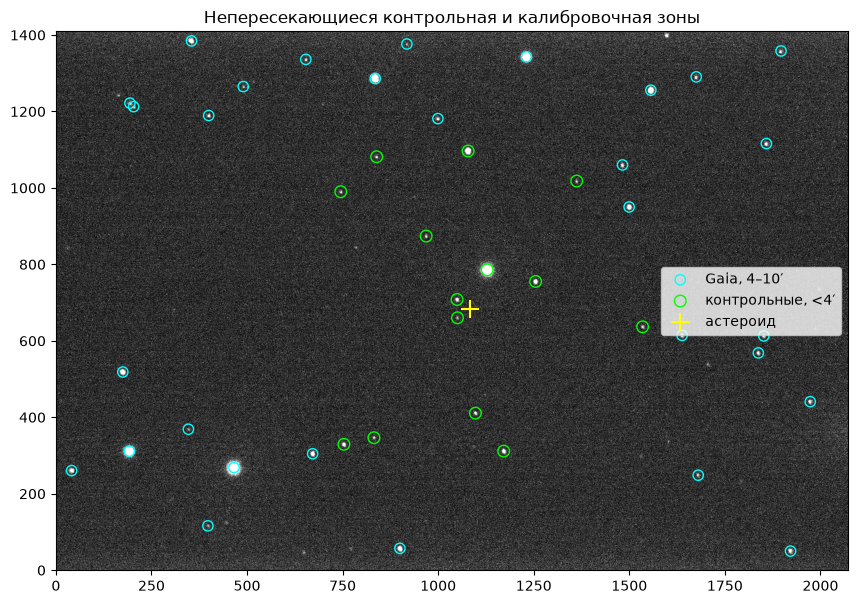

In [6]:
image0, header0 = read_frame(FRAME_PATHS[0])
time0 = middle_time(header0)
wcs0 = WCS(header0)
catalog0 = gaia_at_time(time0)
predicted0 = wcs0.all_world2pix(
    catalog0[["ra_epoch", "dec_epoch"]].to_numpy(), 0
)

asteroid_ra0, asteroid_dec0 = asteroid_coordinates(time0)
asteroid_xy0 = wcs0.all_world2pix([[asteroid_ra0, asteroid_dec0]], 0)[0]
separation0 = SkyCoord(
    catalog0.ra_epoch, catalog0.dec_epoch, unit="deg"
).separation(SkyCoord(asteroid_ra0, asteroid_dec0, unit="deg")).arcmin

inside0 = (
    (predicted0[:, 0] > 20)
    & (predicted0[:, 0] < image0.shape[1] - 20)
    & (predicted0[:, 1] > 20)
    & (predicted0[:, 1] < image0.shape[0] - 20)
)
inner0 = inside0 & (separation0 < INNER_RADIUS_ARCMIN)
outer0 = inside0 & (separation0 >= INNER_RADIUS_ARCMIN) & (
    separation0 < OUTER_RADIUS_ARCMIN
)

print(f"Внутренних контрольных звёзд: {inner0.sum()}")
print(f"Внешних Gaia-калибраторов: {outer0.sum()}")

low, high = np.percentile(image0, (10, 99.7))
fig, ax = plt.subplots(figsize=(11, 7))
ax.imshow(image0, origin="lower", vmin=low, vmax=high)
ax.scatter(
    predicted0[outer0, 0], predicted0[outer0, 1],
    s=55, facecolors="none", edgecolors="cyan", label="Gaia, 4–10′",
)
ax.scatter(
    predicted0[inner0, 0], predicted0[inner0, 1],
    s=70, facecolors="none", edgecolors="lime", label="контрольные, <4′",
)
ax.scatter(*asteroid_xy0, marker="+", s=180, color="yellow", label="астероид")
ax.set_title("Непересекающиеся контрольная и калибровочная зоны")
ax.legend()
plt.show()

## 6. Обработка всех кадров

На каждом кадре внешняя модель вычисляется заново. Координаты внутренних звёзд, полученные через внешнюю модель, сравниваются с Gaia. Их среднее O−C затем вычитается из измеренной координаты астероида.

Одновременно сохраняются положения измеренных звёзд: позднее из них будет построена PSF.

In [7]:
frame_models = []
quality_rows = []
control_rows = []
distortion_rows = []

for frame_number, path in enumerate(FRAME_PATHS):
    image, header = read_frame(path)
    time = middle_time(header)
    wcs = WCS(header)
    catalog = gaia_at_time(time)
    asteroid_ra, asteroid_dec = asteroid_coordinates(time)

    predicted = wcs.all_world2pix(
        catalog[["ra_epoch", "dec_epoch"]].to_numpy(), 0
    )
    separation = SkyCoord(
        catalog.ra_epoch, catalog.dec_epoch, unit="deg"
    ).separation(SkyCoord(asteroid_ra, asteroid_dec, unit="deg")).arcmin

    inside = (
        (predicted[:, 0] > 20)
        & (predicted[:, 0] < image.shape[1] - 20)
        & (predicted[:, 1] > 20)
        & (predicted[:, 1] < image.shape[0] - 20)
    )
    inner = inside & (separation < INNER_RADIUS_ARCMIN)
    outer = inside & (separation >= INNER_RADIUS_ARCMIN) & (
        separation < OUTER_RADIUS_ARCMIN
    )

    catalog_indices = np.where(inner | outer)[0]
    measured_xy = np.array([
        centroid_star(image, *predicted[index]) for index in catalog_indices
    ])
    measured_ok = np.isfinite(measured_xy).all(axis=1)
    catalog_indices = catalog_indices[measured_ok]
    measured_xy = measured_xy[measured_ok]
    is_inner = inner[catalog_indices]
    is_outer = outer[catalog_indices]

    outer_true = tangent_plane(
        catalog.ra_epoch.to_numpy()[catalog_indices[is_outer]],
        catalog.dec_epoch.to_numpy()[catalog_indices[is_outer]],
    )
    coefficients, outer_residual, fit_good = fit_outer_model(
        measured_xy[is_outer], outer_true
    )

    inner_design = np.column_stack([
        np.ones(is_inner.sum()), measured_xy[is_inner]
    ])
    inner_observed = inner_design @ coefficients
    inner_catalog = tangent_plane(
        catalog.ra_epoch.to_numpy()[catalog_indices[is_inner]],
        catalog.dec_epoch.to_numpy()[catalog_indices[is_inner]],
    )
    inner_oc_mas = (inner_observed - inner_catalog) * 3_600_000
    local_correction_deg = inner_oc_mas.mean(axis=0) / 3_600_000
    all_design = np.column_stack([np.ones(len(measured_xy)), measured_xy])
    all_catalog = tangent_plane(
        catalog.ra_epoch.to_numpy()[catalog_indices],
        catalog.dec_epoch.to_numpy()[catalog_indices],
    )
    all_oc_mas = (all_design @ coefficients - all_catalog) * 3_600_000

    outer_rms = np.sqrt(np.mean(np.sum(outer_residual[fit_good] ** 2, axis=1)))
    inner_rms_before = np.sqrt(np.mean(np.sum(inner_oc_mas ** 2, axis=1)))
    centered_inner_oc = inner_oc_mas - inner_oc_mas.mean(axis=0)
    inner_rms_after = np.sqrt(np.mean(np.sum(centered_inner_oc ** 2, axis=1)))

    measured_stars = pd.DataFrame({
        "source_id": catalog.source_id.to_numpy()[catalog_indices],
        "x": measured_xy[:, 0],
        "y": measured_xy[:, 1],
        "gmag": catalog.phot_g_mean_mag.to_numpy()[catalog_indices],
        "separation_arcmin": separation[catalog_indices],
    })

    frame_models.append({
        "coefficients": coefficients,
        "correction": local_correction_deg,
        "time": time,
        "image": image,
        "asteroid_ra": asteroid_ra,
        "asteroid_dec": asteroid_dec,
        "stars": measured_stars,
    })
    quality_rows.append((
        frame_number, path.name, is_outer.sum(), fit_good.sum(), is_inner.sum(),
        outer_rms, inner_rms_before, inner_rms_after,
        *inner_oc_mas.mean(axis=0),
    ))
    for source_id, oc in zip(
        catalog.source_id.to_numpy()[catalog_indices[is_inner]], inner_oc_mas
    ):
        control_rows.append((frame_number, int(source_id), oc[0], oc[1]))
    outer_fit_used = np.zeros(len(measured_xy), dtype=bool)
    outer_fit_used[np.where(is_outer)[0][fit_good]] = True
    for star_index, oc in enumerate(all_oc_mas):
        distortion_rows.append((
            frame_number, path.name,
            int(catalog.source_id.to_numpy()[catalog_indices[star_index]]),
            measured_xy[star_index, 0], measured_xy[star_index, 1],
            oc[0], oc[1], bool(is_inner[star_index]),
            bool(is_outer[star_index]), bool(outer_fit_used[star_index]),
        ))

    # Более слабые Gaia-звёзды не меняют покадровую привязку, но дают
    # дополнительные независимые точки для диагностической карты.
    extra_catalog = gaia_at_time(time, gaia_catalog_extra)
    extra_predicted = wcs.all_world2pix(
        extra_catalog[["ra_epoch", "dec_epoch"]].to_numpy(), 0
    )
    extra_inside = (
        (extra_predicted[:, 0] > 20)
        & (extra_predicted[:, 0] < image.shape[1] - 20)
        & (extra_predicted[:, 1] > 20)
        & (extra_predicted[:, 1] < image.shape[0] - 20)
    )
    extra_indices = np.where(extra_inside)[0]
    extra_measured = np.array([
        centroid_star(image, *extra_predicted[index]) for index in extra_indices
    ])
    extra_ok = np.isfinite(extra_measured).all(axis=1)
    extra_indices = extra_indices[extra_ok]
    extra_measured = extra_measured[extra_ok]
    extra_design = np.column_stack([np.ones(len(extra_measured)), extra_measured])
    extra_catalog_xy = tangent_plane(
        extra_catalog.ra_epoch.to_numpy()[extra_indices],
        extra_catalog.dec_epoch.to_numpy()[extra_indices],
    )
    extra_oc_mas = (extra_design @ coefficients - extra_catalog_xy) * 3_600_000
    extra_separation = SkyCoord(
        extra_catalog.ra_epoch.to_numpy()[extra_indices],
        extra_catalog.dec_epoch.to_numpy()[extra_indices], unit="deg",
    ).separation(SkyCoord(asteroid_ra, asteroid_dec, unit="deg")).arcmin
    for star_index, oc in enumerate(extra_oc_mas):
        separation_value = extra_separation[star_index]
        distortion_rows.append((
            frame_number, path.name, int(extra_catalog.source_id.to_numpy()[extra_indices[star_index]]),
            extra_measured[star_index, 0], extra_measured[star_index, 1],
            oc[0], oc[1], bool(separation_value < INNER_RADIUS_ARCMIN),
            bool(INNER_RADIUS_ARCMIN <= separation_value < OUTER_RADIUS_ARCMIN), False,
        ))

quality = pd.DataFrame(quality_rows, columns=[
    "frame", "filename", "outer_measured", "outer_used", "inner",
    "outer_rms_mas", "inner_rms_before_mas", "inner_rms_after_mas",
    "correction_xi_mas", "correction_eta_mas",
])
control_oc = pd.DataFrame(control_rows, columns=[
    "frame", "source_id", "oc_xi_mas", "oc_eta_mas",
])
distortion_samples = pd.DataFrame(distortion_rows, columns=[
    "frame", "filename", "source_id", "x", "y",
    "oc_xi_mas", "oc_eta_mas", "is_inner", "is_outer",
    "outer_fit_used",
])

## 7. Отбраковка плохих кадров

Критерий использует только внешние звёзды и задаётся **до измерения астероида**:

`предел = медиана RMS + 3 × 1.4826 × MAD`.

Так остатки астероида не могут повлиять на решение, какой кадр считать плохим.

Медианный RMS внешней модели: 123.7 mas
Предел качества: 187.6 mas
Отброшено кадров: 6 из 98
Медианный RMS контрольных звёзд: 188.5 → 167.8 mas


,frame,outer_measured,outer_used,inner,outer_rms_mas,inner_rms_before_mas,inner_rms_after_mas,correction_xi_mas,correction_eta_mas
min,0.0,26.0,18.0,13.0,75.3,141.6,122.6,-182.0,-126.5
50%,48.5,28.0,23.0,14.0,123.7,188.5,167.8,-49.9,4.4
max,97.0,30.0,27.0,14.0,274.5,1094.8,1032.0,115.0,336.6


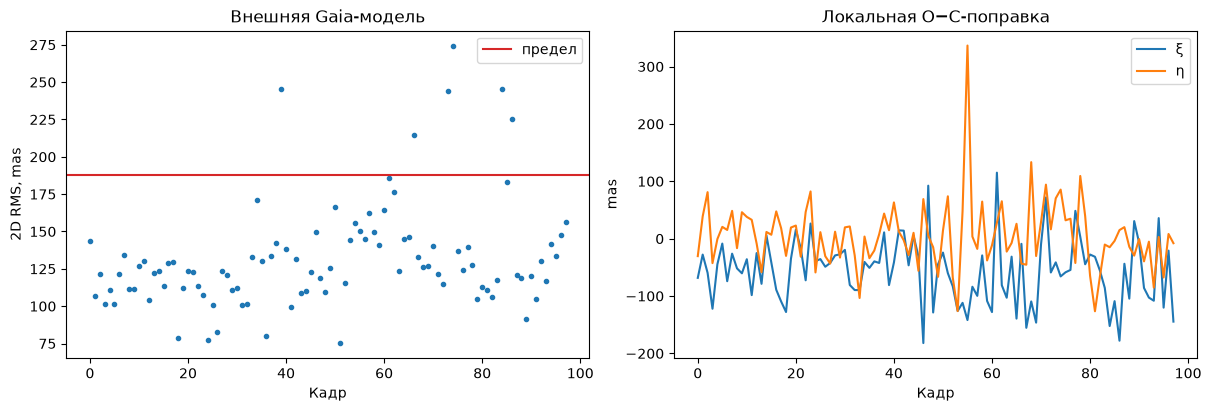

In [8]:
rms_median = quality.outer_rms_mas.median()
rms_robust_sigma = 1.4826 * np.median(
    np.abs(quality.outer_rms_mas - rms_median)
)
frame_rms_limit = rms_median + 3 * rms_robust_sigma
quality["accepted"] = quality.outer_rms_mas <= frame_rms_limit

print(f"Медианный RMS внешней модели: {rms_median:.1f} mas")
print(f"Предел качества: {frame_rms_limit:.1f} mas")
print(f"Отброшено кадров: {(~quality.accepted).sum()} из {len(quality)}")
print(
    "Медианный RMS контрольных звёзд: "
    f"{quality.inner_rms_before_mas.median():.1f} → "
    f"{quality.inner_rms_after_mas.median():.1f} mas"
)

display(
    quality.describe().loc[["min", "50%", "max"]].round(1)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(quality.outer_rms_mas, ".")
axes[0].axhline(frame_rms_limit, color="tab:red", label="предел")
axes[0].set(xlabel="Кадр", ylabel="2D RMS, mas", title="Внешняя Gaia-модель")
axes[0].legend()
axes[1].plot(quality.correction_xi_mas, label="ξ")
axes[1].plot(quality.correction_eta_mas, label="η")
axes[1].set(xlabel="Кадр", ylabel="mas", title="Локальная O−C-поправка")
axes[1].legend()
plt.show()

## 8. Вырезки астероида в локально исправленной системе

Если среднее звёздное O−C равно `e`, истинный объект ожидается в пикселе, для которого внешняя модель даёт `эфемерида + e`. После центрирования по этому пикселю измеренный сдвиг астероида уже соответствует локально исправленному O−C.

In [9]:
asteroid_cutouts = [None] * len(frame_models)

for frame_number, model in enumerate(frame_models):
    if not quality.accepted.iloc[frame_number]:
        continue

    expected_tangent = tangent_plane(
        [model["asteroid_ra"]], [model["asteroid_dec"]]
    )[0]
    expected_tangent += model["correction"]

    coefficients = model["coefficients"]
    asteroid_xy = np.linalg.solve(
        coefficients[1:].T,
        expected_tangent - coefficients[0],
    )
    ix, iy = np.round(asteroid_xy).astype(int)
    half = STACK_HALF_SIZE
    cutout = model["image"][iy-half:iy+half+1, ix-half:ix+half+1]
    _, background, _ = sigma_clipped_stats(cutout, sigma=3)

    fractional_shift = (
        -(asteroid_xy[1] - iy),
        -(asteroid_xy[0] - ix),
    )
    asteroid_cutouts[frame_number] = image_shift(
        cutout - background,
        fractional_shift,
        order=1,
        mode="constant",
        cval=np.nan,
        prefilter=False,
    )

## 9. Пять независимых стеков

Сохраняются исходные временные блоки по 20 кадров. Плохие кадры внутри блока не складываются, поэтому группы остаются независимыми и не перемешиваются по времени.

In [10]:
stack_groups = []

for start in range(0, len(asteroid_cutouts), GROUP_SIZE):
    stop = min(start + GROUP_SIZE, len(asteroid_cutouts))
    frame_indices = [
        index for index in range(start, stop)
        if asteroid_cutouts[index] is not None
    ]
    assert len(frame_indices) >= 10, "В стеке осталось слишком мало кадров"

    cube = np.stack([asteroid_cutouts[index] for index in frame_indices])
    stack = np.ma.mean(
        sigma_clip(cube, sigma=3, axis=0), axis=0
    ).filled(np.nan)
    middle_jd = np.mean([
        frame_models[index]["time"].jd for index in frame_indices
    ])
    span_minutes = (
        frame_models[frame_indices[-1]]["time"]
        - frame_models[frame_indices[0]]["time"]
    ).to_value("min")

    stack_groups.append({
        "frame_indices": frame_indices,
        "image": stack,
        "middle_jd": middle_jd,
        "span_minutes": span_minutes,
    })

print("Число хороших кадров в стеках:", [
    len(group["frame_indices"]) for group in stack_groups
])
print(
    f"Медианная длительность: "
    f"{np.median([group['span_minutes'] for group in stack_groups]):.2f} мин"
)

Число хороших кадров в стеках: [20, 19, 20, 17, 16]
Медианная длительность: 4.10 мин


## 10. Эмпирическая звёздная PSF

Для каждого стека строится своя PSF:

1. берутся звёзды не дальше 8′ от астероида и `14.5 < G < 16.5`;
2. сатурированные и слишком слабые изображения исключаются;
3. у каждой звезды вычитается локальный фон;
4. изображения центрируются с субпиксельной точностью и нормируются на единичный поток;
5. сотни изображений объединяются с sigma-clipping.

Радиус 8′ сохраняет локальность PSF и одновременно даёт достаточно большую выборку.

Звёздных изображений в PSF: [500, 472, 482, 422, 400]


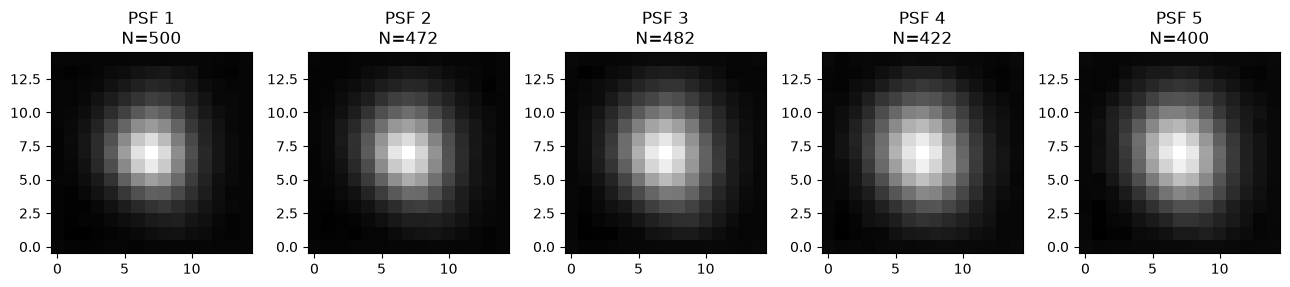

In [11]:
psf_size = 2 * PSF_HALF_SIZE + 1
psf_y, psf_x = np.indices((psf_size, psf_size))
psf_radius = np.hypot(psf_x - PSF_HALF_SIZE, psf_y - PSF_HALF_SIZE)


def normalized_star_stamp(image, x, y):
    '''Вернуть центрированное изображение звезды с единичным потоком.'''
    half = PSF_HALF_SIZE
    ix = int(round(x))
    iy = int(round(y))
    stamp = image[iy-half:iy+half+1, ix-half:ix+half+1]
    if stamp.shape != (psf_size, psf_size):
        return None

    background = np.median(stamp[psf_radius > 5.5])
    signal = stamp - background
    flux = np.sum(signal[psf_radius < 5.5])
    peak = np.max(stamp)
    if flux <= 5000 or peak >= 50000:
        return None

    center_in_stamp = (x - (ix - half), y - (iy - half))
    shift_y = half - center_in_stamp[1]
    shift_x = half - center_in_stamp[0]
    aligned = image_shift(
        signal,
        (shift_y, shift_x),
        order=3,
        mode="constant",
        cval=0,
        prefilter=True,
    )
    normalization = np.sum(aligned[psf_radius < 5.5])
    if normalization <= 0:
        return None
    return aligned / normalization


def build_group_psf(group):
    stamps = []
    for frame_number in group["frame_indices"]:
        model = frame_models[frame_number]
        stars = model["stars"]
        selected = stars[
            stars.gmag.between(PSF_MAG_MIN, PSF_MAG_MAX)
            & (stars.separation_arcmin < PSF_RADIUS_ARCMIN)
        ]
        for star in selected.itertuples():
            stamp = normalized_star_stamp(
                model["image"], star.x, star.y
            )
            if stamp is not None:
                stamps.append(stamp)

    cube = np.stack(stamps)
    psf = np.ma.mean(
        sigma_clip(cube, sigma=3, axis=0), axis=0
    ).filled(0)
    psf /= psf.sum()
    return psf, len(stamps)


for group in stack_groups:
    group["psf"], group["psf_star_images"] = build_group_psf(group)

print("Звёздных изображений в PSF:", [
    group["psf_star_images"] for group in stack_groups
])

fig, axes = plt.subplots(1, len(stack_groups), figsize=(13, 3))
for number, (group, ax) in enumerate(zip(stack_groups, axes), start=1):
    ax.imshow(group["psf"], origin="lower")
    ax.set_title(f"PSF {number}\nN={group['psf_star_images']}")
plt.tight_layout()
plt.show()

## 11. Две модели центра: гауссиана и звёздная PSF

Обе модели применяются к одним и тем же стекам. Это позволяет честно проверить, даёт ли PSF улучшение. В PSF-модели подбираются только фон, поток и два смещения.

In [12]:
FIT_HALF_SIZE = PSF_HALF_SIZE


def gaussian_2d(coordinates, background, amplitude, x0, y0, sigma_x, sigma_y):
    x, y = coordinates
    exponent = ((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2
    return (background + amplitude * np.exp(-0.5 * exponent)).ravel()


def fit_gaussian(stack):
    center = STACK_HALF_SIZE
    half = FIT_HALF_SIZE
    data = stack[center-half:center+half+1, center-half:center+half+1]
    y, x = np.indices(data.shape)
    peak_y, peak_x = np.unravel_index(np.nanargmax(data), data.shape)
    background = np.nanmedian(data[psf_radius > 5.5])
    initial = [
        background, np.nanmax(data) - background,
        peak_x, peak_y, 2.0, 2.0,
    ]
    parameters, covariance = curve_fit(
        gaussian_2d,
        (x, y),
        data.ravel(),
        p0=initial,
        bounds=([-np.inf, 0, 2, 2, 0.7, 0.7],
                [np.inf, np.inf, 12, 12, 6, 6]),
        maxfev=20_000,
    )
    dx = parameters[2] - half
    dy = parameters[3] - half
    return dx, dy, parameters, covariance


def fit_empirical_psf(stack, psf):
    center = STACK_HALF_SIZE
    half = FIT_HALF_SIZE
    data = stack[center-half:center+half+1, center-half:center+half+1]
    peak_y, peak_x = np.unravel_index(np.nanargmax(data), data.shape)
    background = np.nanmedian(data[psf_radius > 5.5])

    def residual(parameters):
        background, flux, dx, dy = parameters
        shifted_psf = image_shift(
            psf, (dy, dx), order=3, mode="constant", cval=0, prefilter=True
        )
        model = background + flux * shifted_psf
        return (model - data).ravel()

    initial = [
        background,
        max(1, np.sum(data - background)),
        peak_x - half,
        peak_y - half,
    ]
    fit = least_squares(
        residual,
        initial,
        bounds=([-np.inf, 0, -5, -5], [np.inf, np.inf, 5, 5]),
    )
    return fit.x[2], fit.x[3], fit.x, fit.cost


def pixel_offset_to_mas(group, dx, dy):
    jacobians = [
        frame_models[index]["coefficients"][1:].T
        for index in group["frame_indices"]
    ]
    mean_jacobian = np.mean(jacobians, axis=0)
    return mean_jacobian @ np.array([dx, dy]) * 3_600_000

In [13]:
measurement_rows = []

for group_number, group in enumerate(stack_groups, start=1):
    stack = group["image"]
    gaussian_dx, gaussian_dy, gaussian_parameters, _ = fit_gaussian(stack)
    psf_dx, psf_dy, psf_parameters, psf_cost = fit_empirical_psf(
        stack, group["psf"]
    )
    gaussian_oc = pixel_offset_to_mas(group, gaussian_dx, gaussian_dy)
    psf_oc = pixel_offset_to_mas(group, psf_dx, psf_dy)

    center = STACK_HALF_SIZE
    y, x = np.indices(stack.shape)
    background_mask = np.hypot(x - center, y - center) > 10
    _, background, noise = sigma_clipped_stats(stack[background_mask], sigma=3)
    peak_snr = (np.nanmax(stack) - background) / noise

    measurement_rows.append((
        group_number,
        len(group["frame_indices"]),
        group["middle_jd"],
        group["span_minutes"],
        *gaussian_oc,
        *psf_oc,
        peak_snr,
        group["psf_star_images"],
    ))

stacks = pd.DataFrame(measurement_rows, columns=[
    "group", "frames", "middle_jd", "span_minutes",
    "gaussian_xi_mas", "gaussian_eta_mas",
    "psf_xi_mas", "psf_eta_mas",
    "snr", "psf_star_images",
])
stacks["middle_utc"] = Time(stacks.middle_jd, format="jd").isot

display(stacks[[
    "group", "frames", "middle_utc", "gaussian_xi_mas",
    "gaussian_eta_mas", "psf_xi_mas", "psf_eta_mas", "snr",
]].round(2))

,group,frames,middle_utc,gaussian_xi_mas,gaussian_eta_mas,psf_xi_mas,psf_eta_mas,snr
0,1,20,2025-09-03T21:12:18.101,40.03,52.41,45.52,60.04,15.26
1,2,19,2025-09-03T21:17:27.855,-7.66,-25.55,-4.88,3.47,12.94
2,3,20,2025-09-03T21:22:28.807,54.62,-62.26,57.91,-17.10,13.76
3,4,17,2025-09-03T21:26:39.357,-6.83,5.36,-2.35,25.89,10.92
4,5,16,2025-09-03T21:30:42.522,97.48,0.97,111.29,34.65,9.91


## 12. Изображения стеков

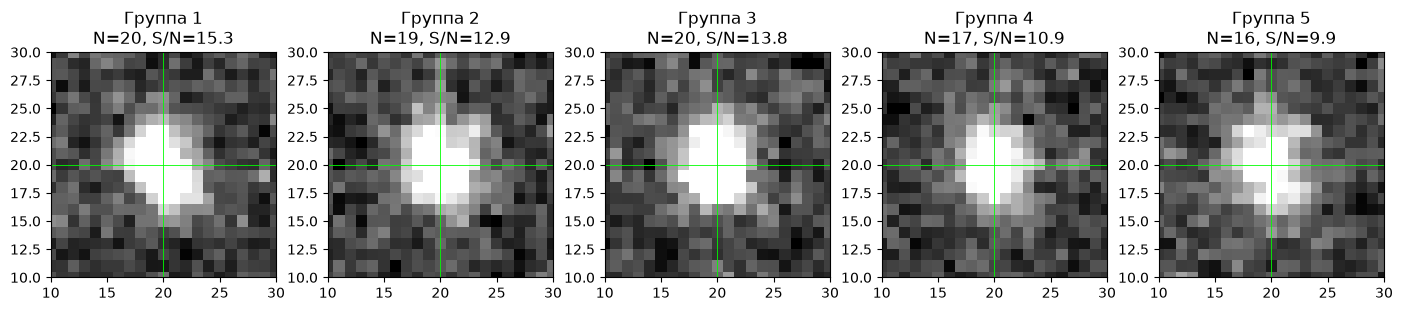

In [14]:
fig, axes = plt.subplots(1, len(stack_groups), figsize=(14, 3.2))
for row, group, ax in zip(stacks.itertuples(), stack_groups, axes):
    stack = group["image"]
    _, background, noise = sigma_clipped_stats(stack, sigma=3)
    ax.imshow(
        stack, origin="lower",
        vmin=background - 2 * noise,
        vmax=background + 6 * noise,
    )
    ax.axvline(STACK_HALF_SIZE, color="lime", linewidth=0.6)
    ax.axhline(STACK_HALF_SIZE, color="lime", linewidth=0.6)
    ax.set_xlim(STACK_HALF_SIZE - 10, STACK_HALF_SIZE + 10)
    ax.set_ylim(STACK_HALF_SIZE - 10, STACK_HALF_SIZE + 10)
    ax.set_title(f"Группа {row.group}\nN={row.frames}, S/N={row.snr:.1f}")
plt.tight_layout()
plt.show()

## 13. Линейная модель серии и RMS

Для каждой модели O−C аппроксимируется прямой по времени. Приводятся два RMS:

- обычный RMS остатков с делителем `n`;
- скорректированный RMS с делителем `n−2`, потому что из пяти точек определены наклон и свободный член.

При пяти стеках скорректированная величина является более осторожной оценкой.

In [15]:
def fit_time_series(table, prefix):
    minutes = (table.middle_jd - table.middle_jd.mean()) * 1440
    xi = table[f"{prefix}_xi_mas"].to_numpy()
    eta = table[f"{prefix}_eta_mas"].to_numpy()

    line_xi, covariance_xi = np.polyfit(minutes, xi, 1, cov=True)
    line_eta, covariance_eta = np.polyfit(minutes, eta, 1, cov=True)
    residual_xi = xi - np.polyval(line_xi, minutes)
    residual_eta = eta - np.polyval(line_eta, minutes)

    rms_xi = np.sqrt(np.mean(residual_xi ** 2))
    rms_eta = np.sqrt(np.mean(residual_eta ** 2))
    rms_2d = np.hypot(rms_xi, rms_eta)
    rms_adjusted = np.sqrt(
        np.sum(residual_xi ** 2 + residual_eta ** 2) / (len(table) - 2)
    )
    return {
        "minutes": minutes,
        "line_xi": line_xi,
        "line_eta": line_eta,
        "residual_xi": residual_xi,
        "residual_eta": residual_eta,
        "error_xi": np.sqrt(covariance_xi[1, 1]),
        "error_eta": np.sqrt(covariance_eta[1, 1]),
        "rms_xi": rms_xi,
        "rms_eta": rms_eta,
        "rms_2d": rms_2d,
        "rms_adjusted": rms_adjusted,
    }


gaussian_result = fit_time_series(stacks, "gaussian")
psf_result = fit_time_series(stacks, "psf")

comparison = pd.DataFrame([
    (
        "Свободная гауссиана",
        gaussian_result["rms_xi"], gaussian_result["rms_eta"],
        gaussian_result["rms_2d"], gaussian_result["rms_adjusted"],
    ),
    (
        "Звёздная PSF",
        psf_result["rms_xi"], psf_result["rms_eta"],
        psf_result["rms_2d"], psf_result["rms_adjusted"],
    ),
], columns=["model", "RMS_xi_mas", "RMS_eta_mas", "RMS_2D_mas", "RMS_2D_n_minus_2_mas"])
display(comparison.round(1))

,model,RMS_xi_mas,RMS_eta_mas,RMS_2D_mas,RMS_2D_n_minus_2_mas
0,Свободная гауссиана,36.6,35.8,51.2,66.1
1,Звёздная PSF,39.1,25.9,46.9,60.5


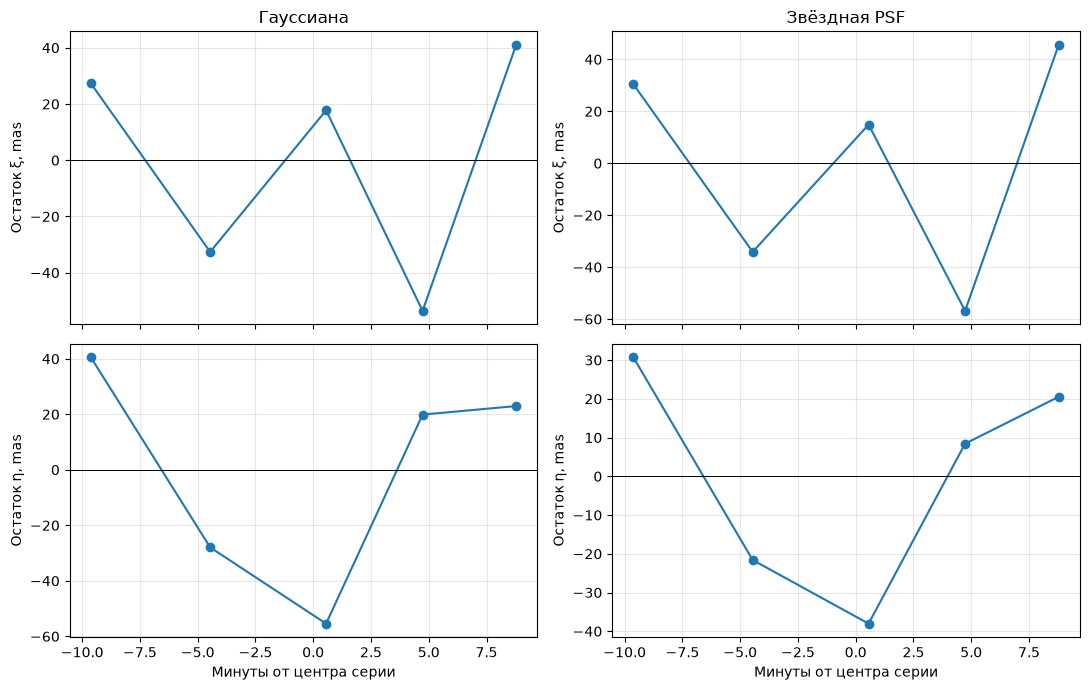

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for column, (name, result) in enumerate([
    ("Гауссиана", gaussian_result),
    ("Звёздная PSF", psf_result),
]):
    axes[0, column].plot(result["minutes"], result["residual_xi"], "o-")
    axes[1, column].plot(result["minutes"], result["residual_eta"], "o-")
    axes[0, column].set_title(name)
    axes[0, column].set_ylabel("Остаток ξ, mas")
    axes[1, column].set_ylabel("Остаток η, mas")
    axes[1, column].set_xlabel("Минуты от центра серии")
    for row in range(2):
        axes[row, column].axhline(0, color="black", linewidth=0.7)
        axes[row, column].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Итоговая координата по звёздной PSF

Значение прямой PSF-O−C в центральный момент добавляется к эфемеридному положению. Horizons определяет только исходную точку сравнения; измеренное O−C получено из изображения.

In [17]:
central_time = Time(stacks.middle_jd.mean(), format="jd", scale="utc")
ephemeris_ra, ephemeris_dec = asteroid_coordinates(central_time)
ephemeris_tangent = tangent_plane([ephemeris_ra], [ephemeris_dec])[0]

measured_tangent = ephemeris_tangent + np.array([
    psf_result["line_xi"][1], psf_result["line_eta"][1]
]) / 3_600_000
measured_ra, measured_dec = inverse_tangent(*measured_tangent)

summary = pd.DataFrame({
    "quantity": [
        "central_utc", "RA_deg", "Dec_deg",
        "O-C_xi_mas", "O-C_eta_mas",
        "error_xi_mas", "error_eta_mas",
        "RMS_xi_mas", "RMS_eta_mas", "RMS_2D_mas",
        "RMS_2D_adjusted_mas", "median_stack_SNR",
    ],
    "value": [
        central_time.isot, measured_ra, measured_dec,
        psf_result["line_xi"][1], psf_result["line_eta"][1],
        psf_result["error_xi"], psf_result["error_eta"],
        psf_result["rms_xi"], psf_result["rms_eta"],
        psf_result["rms_2d"], psf_result["rms_adjusted"],
        stacks.snr.median(),
    ],
})
display(summary)

print(f"Результат на {central_time.isot}")
print(f"RA  = {measured_ra:.8f}°")
print(f"Dec = {measured_dec:.8f}°")
print(
    f"PSF RMS: ξ={psf_result['rms_xi']:.1f}, "
    f"η={psf_result['rms_eta']:.1f}, "
    f"2D={psf_result['rms_2d']:.1f} mas"
)
print(f"PSF 2D RMS с поправкой n−2: {psf_result['rms_adjusted']:.1f} mas")

,quantity,value
0,central_utc,2025-09-03T21:21:55.329
1,RA_deg,43.487979
2,Dec_deg,15.440525
3,O-C_xi_mas,41.498551
4,O-C_eta_mas,21.389909
5,error_xi_mas,22.55387
6,error_eta_mas,14.940115
7,RMS_xi_mas,39.064449
8,RMS_eta_mas,25.877039
9,RMS_2D_mas,46.857788


Результат на 2025-09-03T21:21:55.329
RA  = 43.48797876°
Dec = 15.44052461°
PSF RMS: ξ=39.1, η=25.9, 2D=46.9 mas
PSF 2D RMS с поправкой n−2: 60.5 mas


## 15. Сохранение таблиц

In [18]:
quality.to_csv(
    OUTPUT_DIR / "two_zone_frame_quality_20250903_R.csv", index=False
)
control_oc.to_csv(
    OUTPUT_DIR / "two_zone_control_oc_20250903_R.csv", index=False
)
distortion_samples.to_csv(
    OUTPUT_DIR / "two_zone_distortion_samples_20250903_R.csv", index=False
)
stacks.to_csv(
    OUTPUT_DIR / "two_zone_asteroid_stacks_20250903_R.csv", index=False
)
comparison.to_csv(
    OUTPUT_DIR / "two_zone_model_comparison_20250903_R.csv", index=False
)
summary.to_csv(
    OUTPUT_DIR / "two_zone_result_20250903_R.csv", index=False
)
print(f"Таблицы сохранены в {OUTPUT_DIR.resolve()}")

Таблицы сохранены в /home/fanat/vlad/science/Fredschaaf/outputs


## Вывод

Эмпирическая PSF использует реальную форму звёзд данного телескопа и данной группы кадров. Она уменьшает число свободных параметров слабого объекта и позволяет проверить, не связан ли большой разброс с неустойчивыми ширинами гауссианы.

Выбор PSF-звёзд основан только на их блеске, отсутствии насыщения и расстоянии от астероида. Кадры отбраковываются только по внешней Gaia-модели. Положения и остатки самого астероида нигде не используются для отбора данных.